betül danışmaz


In [1]:
# Step 1.1: Kaggle Login
import kagglehub
kagglehub.login()

Kaggle credentials set.
Kaggle credentials successfully validated.


In [4]:
# Step 1.2: Download Competition Data
yzta_2026_datathon_path = kagglehub.competition_download('yzta-2026-datathon')
print('Data source import complete.')

Data source import complete.


In [5]:
# Step 1.3: File Organization
import os
import shutil
dest_dir = '/content/yzta-2026-datathon'
os.makedirs(dest_dir, exist_ok=True)
for file in os.listdir(yzta_2026_datathon_path):
    shutil.copy(os.path.join(yzta_2026_datathon_path, file), dest_dir)
yzta_2026_datathon_path = dest_dir

In [6]:
import os

data_path = "/content/yzta-2026-datathon"

print(os.listdir(data_path))


['train.csv', 'test_x.csv', 'sample_submission.csv']


In [7]:
# Step 1.4: Load DataFrames
import pandas as pd
import numpy as np
train = pd.read_csv(os.path.join(data_path, 'train.csv'))
test = pd.read_csv(os.path.join(data_path, 'test_x.csv'))
sample_submission = pd.read_csv(os.path.join(data_path, 'sample_submission.csv'))

In [8]:
print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Sample submission shape:", sample_submission.shape)

display(train.head())
display(test.head())
display(sample_submission.head())

Train shape: (56000, 24)
Test shape: (24000, 23)
Sample submission shape: (2, 2)


,id,yas,cinsiyet,meslek,vucut_kitle_indeksi,ulke,rem_yuzdesi,derin_uyku_yuzdesi,uykuya_dalma_suresi_dk,gecelik_uyanma_sayisi,...,stres_skoru,gunluk_calisma_saati,kronotip,ruh_sagligi_durumu,dinlenik_nabiz_bpm,oda_sicakligi_celsius,hafta_sonu_uyku_farki_saat,mevsim,gun_tipi,bilissel_performans_skoru
0,1,34,Erkek,Saglik Personeli,31.470103,Cin,14.431210,14.645436,27,7,...,9.922976,10.045274,Sabah insani,Anksiyete ve depresyon,78,18.962436,-0.074140,Sonbahar-Kis,Hafta ici,0.136441
1,2,32,Kadin,Muhendis,30.981394,Amerika,21.771870,27.220360,20,4,...,6.626400,6.319245,Gece insani,Saglikli,76,21.225666,0.942672,Sonbahar-Kis,Hafta ici,5.848312
2,3,39,Erkek,Ev Hanimi,21.533898,Spain,18.178857,25.530104,33,7,...,6.093566,3.824463,Notr,Depresyon,66,18.482409,1.239886,Ilkbahar-Yaz,Hafta sonu,6.828276
3,4,40,Kadin,Egitimci,23.310749,Yeni Zelanda,21.438151,15.891188,21,2,...,3.168185,4.597316,Gece insani,Saglikli,60,21.862235,0.727695,Sonbahar-Kis,Hafta sonu,8.144649
4,5,36,Kadin,NaN,NaN,Portekiz,25.468018,16.356738,21,8,...,7.198574,3.189120,Notr,Anksiyete ve depresyon,74,19.223195,-0.223402,Sonbahar-Kis,Hafta ici,0.431423


,id,yas,cinsiyet,meslek,vucut_kitle_indeksi,ulke,rem_yuzdesi,derin_uyku_yuzdesi,uykuya_dalma_suresi_dk,gecelik_uyanma_sayisi,...,sekerleme_suresi_dk,stres_skoru,gunluk_calisma_saati,kronotip,ruh_sagligi_durumu,dinlenik_nabiz_bpm,oda_sicakligi_celsius,hafta_sonu_uyku_farki_saat,mevsim,gun_tipi
0,1,42,Erkek,Saglik Personeli,29.728724,Ingiltere,21.691917,23.990157,21,5,...,0,6.349196,9.419561,Gece insani,Depresyon,82,21.627129,1.716161,Ilkbahar-Yaz,Hafta sonu
1,2,26,Kadin,Serbest Calisan,32.865996,Cin,22.090624,18.231963,34,5,...,0,NaN,8.574199,Gece insani,Saglikli,66,27.835934,1.482283,Ilkbahar-Yaz,Hafta ici
2,3,21,Erkek,Lojistik Calisani,24.438264,Cin,19.488438,16.695363,17,4,...,52,6.715192,10.519017,Notr,Depresyon,63,20.252258,1.981034,Sonbahar-Kis,Hafta ici
3,4,61,Kadin,Saglik Personeli,23.275057,Cin,26.831092,21.762040,29,2,...,2,5.633400,9.814789,Gece insani,Saglikli,71,17.680971,0.589750,Sonbahar-Kis,Hafta ici
4,5,26,Kadin,Saglik Personeli,24.815531,Ingiltere,16.271522,18.153212,15,4,...,0,7.953794,9.308398,Sabah insani,Saglikli,53,23.698979,0.622211,Ilkbahar-Yaz,Hafta ici


,id,bilissel_performans_skoru
0,1,7.85
1,2,4.32


In [9]:
print("Train columns:")
print(train.columns.tolist())

print("\nTest columns:")
print(test.columns.tolist())

print("\nSubmission columns:")
print(sample_submission.columns.tolist())

Train columns:
['id', 'yas', 'cinsiyet', 'meslek', 'vucut_kitle_indeksi', 'ulke', 'rem_yuzdesi', 'derin_uyku_yuzdesi', 'uykuya_dalma_suresi_dk', 'gecelik_uyanma_sayisi', 'uyku_oncesi_kafein_mg', 'uyku_oncesi_ekran_suresi_dk', 'gunluk_adim_sayisi', 'sekerleme_suresi_dk', 'stres_skoru', 'gunluk_calisma_saati', 'kronotip', 'ruh_sagligi_durumu', 'dinlenik_nabiz_bpm', 'oda_sicakligi_celsius', 'hafta_sonu_uyku_farki_saat', 'mevsim', 'gun_tipi', 'bilissel_performans_skoru']

Test columns:
['id', 'yas', 'cinsiyet', 'meslek', 'vucut_kitle_indeksi', 'ulke', 'rem_yuzdesi', 'derin_uyku_yuzdesi', 'uykuya_dalma_suresi_dk', 'gecelik_uyanma_sayisi', 'uyku_oncesi_kafein_mg', 'uyku_oncesi_ekran_suresi_dk', 'gunluk_adim_sayisi', 'sekerleme_suresi_dk', 'stres_skoru', 'gunluk_calisma_saati', 'kronotip', 'ruh_sagligi_durumu', 'dinlenik_nabiz_bpm', 'oda_sicakligi_celsius', 'hafta_sonu_uyku_farki_saat', 'mevsim', 'gun_tipi']

Submission columns:
['id', 'bilissel_performans_skoru']


In [10]:
target = "bilissel_performans_skoru"
id_col = "id"

print("Target in train:", target in train.columns)
print("Target in test:", target in test.columns)
print("ID in train:", id_col in train.columns)
print("ID in test:", id_col in test.columns)
print("ID in sample_submission:", id_col in sample_submission.columns)
print("Target in sample_submission:", target in sample_submission.columns)

Target in train: True
Target in test: False
ID in train: True
ID in test: True
ID in sample_submission: True
Target in sample_submission: True


In [11]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56000 entries, 0 to 55999
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           56000 non-null  int64  
 1   yas                          56000 non-null  int64  
 2   cinsiyet                     56000 non-null  object 
 3   meslek                       54622 non-null  object 
 4   vucut_kitle_indeksi          54248 non-null  float64
 5   ulke                         56000 non-null  object 
 6   rem_yuzdesi                  56000 non-null  float64
 7   derin_uyku_yuzdesi           56000 non-null  float64
 8   uykuya_dalma_suresi_dk       56000 non-null  int64  
 9   gecelik_uyanma_sayisi        56000 non-null  int64  
 10  uyku_oncesi_kafein_mg        54537 non-null  float64
 11  uyku_oncesi_ekran_suresi_dk  56000 non-null  int64  
 12  gunluk_adim_sayisi           56000 non-null  int64  
 13  sekerleme_suresi

In [12]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24000 entries, 0 to 23999
Data columns (total 23 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           24000 non-null  int64  
 1   yas                          24000 non-null  int64  
 2   cinsiyet                     24000 non-null  object 
 3   meslek                       23378 non-null  object 
 4   vucut_kitle_indeksi          23352 non-null  float64
 5   ulke                         24000 non-null  object 
 6   rem_yuzdesi                  24000 non-null  float64
 7   derin_uyku_yuzdesi           24000 non-null  float64
 8   uykuya_dalma_suresi_dk       24000 non-null  int64  
 9   gecelik_uyanma_sayisi        24000 non-null  int64  
 10  uyku_oncesi_kafein_mg        23303 non-null  float64
 11  uyku_oncesi_ekran_suresi_dk  24000 non-null  int64  
 12  gunluk_adim_sayisi           24000 non-null  int64  
 13  sekerleme_suresi

In [13]:
train[target].describe()

,bilissel_performans_skoru
count,56000.000000
mean,5.913096
std,2.231759
min,0.000000
25%,4.397431
50%,6.032249
75%,7.574980
max,10.000000


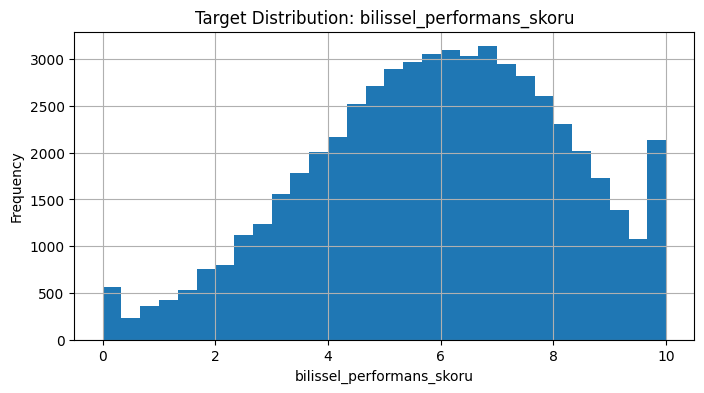

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
train[target].hist(bins=30)
plt.title("Target Distribution: bilissel_performans_skoru")
plt.xlabel("bilissel_performans_skoru")
plt.ylabel("Frequency")
plt.show()

In [15]:
# Step 2.1: Initial X/Y Separation
target = 'bilissel_performans_skoru'
id_col = 'id'
feature_cols = [col for col in train.columns if col not in [target, id_col]]
X = train[feature_cols]
y = train[target]

In [16]:
# Step 2.2: Feature Type Identification
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

In [35]:
# Step 2.3: Domain-Specific Feature Engineering Function
# This function adds sleep-related domain features to the dataset.
def add_domain_features(df, group='all'):
    df_new = df.copy()
    if group in ['sleep', 'all']:
        # Example of creating new features from existing sleep-related ones
        df_new['total_quality_sleep_pct'] = df_new['rem_yuzdesi'] + df_new['derin_uyku_yuzdesi']
        df_new['sleep_fragmentation_idx'] = df_new['gecelik_uyanma_sayisi'] + (df_new['uykuya_dalma_suresi_dk'] / 30.0)
    return df_new


In [17]:
# Check whether train and test have the same feature columns
missing_in_test = set(feature_cols) - set(test.columns)
extra_in_test = set(test.columns) - set(feature_cols) - {id_col}

print("Missing feature columns in test:", missing_in_test)
print("Extra columns in test:", extra_in_test)

Missing feature columns in test: set()
Extra columns in test: set()


In [18]:
print("Missing values in train:")
display(train[feature_cols].isnull().sum().sort_values(ascending=False))

print("\nMissing values in test:")
display(test[feature_cols].isnull().sum().sort_values(ascending=False))

Missing values in train:


,0
kronotip,1968
vucut_kitle_indeksi,1752
stres_skoru,1715
uyku_oncesi_kafein_mg,1463
meslek,1378
ruh_sagligi_durumu,1096
rem_yuzdesi,0
ulke,0
yas,0
cinsiyet,0



Missing values in test:


,0
kronotip,832
stres_skoru,765
uyku_oncesi_kafein_mg,697
vucut_kitle_indeksi,648
meslek,622
ruh_sagligi_durumu,504
rem_yuzdesi,0
ulke,0
yas,0
cinsiyet,0


In [19]:
print("Categorical Cardinality (Unique Values):")
cardinality = train[categorical_features].nunique().sort_values(ascending=False)
display(cardinality)

print("\nTop 5 category frequencies for high-cardinality features:")
for col in cardinality.index[:3]: # Check the top 3 most diverse columns
    print(f"\n--- {col} ---")
    display(train[col].value_counts(normalize=True).head(5))

# Best course of action:
# 1. Use One-Hot Encoding for all categories as the total number of features remains manageable.
# 2. Set handle_unknown='ignore' to robustly manage unseen categories in the test set.
# 3. If cardinality for 'ulke' or 'meslek' is extremely high (>50), consider Target Encoding in later iterations.

Categorical Cardinality (Unique Values):


,0
ulke,15
meslek,11
ruh_sagligi_durumu,4
kronotip,3
cinsiyet,2
mevsim,2
gun_tipi,2



Top 5 category frequencies for high-cardinality features:

--- ulke ---


,proportion
ulke,
Ingiltere,0.202214
Cin,0.178375
Guney Kore,0.079625
Amerika,0.079411
Arjantin,0.070946



--- meslek ---


,proportion
meslek,
Saglik Personeli,0.180184
Ogrenci,0.148878
Muhendis,0.119604
Yonetici,0.081542
Egitimci,0.080462



--- ruh_sagligi_durumu ---


,proportion
ruh_sagligi_durumu,
Saglikli,0.698765
Anksiyete,0.150627
Depresyon,0.100248
Anksiyete ve depresyon,0.050361


CATBOOST VS LIGHTGBM

In [20]:
# Step 3.1: Install Dependencies
!pip install lightgbm catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.3 MB/s eta 0:00:00


In [21]:
# Step 3.2: Evaluation Metrics Definition
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
def evaluate_predictions(y_true, preds, model_name='model'):
    preds = np.clip(preds, 0, 10)
    rmse = np.sqrt(mean_squared_error(y_true, preds))
    print(f'{model_name} RMSE: {rmse:.5f}')
    return rmse

In [22]:
# Step 4.1: Prepare Categorical Data (X_cat)
from sklearn.model_selection import KFold
X_cat = X.copy()
for col in categorical_features:
    X_cat[col] = X_cat[col].fillna('Missing').astype(str)
cat_feature_indices = [X_cat.columns.get_loc(col) for col in categorical_features]

In [23]:
# Step 4.2: Core CV Evaluation Function
from catboost import CatBoostRegressor
def evaluate_catboost_cv(params, X_data, y_data, cat_features, n_splits=5):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    fold_results = []
    for fold, (train_idx, valid_idx) in enumerate(kf.split(X_data), start=1):
        X_tr, X_val = X_data.iloc[train_idx], X_data.iloc[valid_idx]
        y_tr, y_val = y_data.iloc[train_idx], y_data.iloc[valid_idx]
        model = CatBoostRegressor(loss_function='RMSE', eval_metric='RMSE', random_seed=42, verbose=0, **params)
        model.fit(X_tr, y_tr, cat_features=cat_features, eval_set=(X_val, y_val), use_best_model=True, early_stopping_rounds=100)
        preds = np.clip(model.predict(X_val), 0, 10)
        fold_results.append({'fold': fold, 'RMSE': np.sqrt(mean_squared_error(y_val, preds)), 'best_iteration': model.get_best_iteration()})
    return pd.DataFrame(fold_results)

### 5-Fold CV Baseline: Optimized CatBoost
Establishing the benchmark performance with selected hyperparameters.

In [25]:
final_baseline_params = {
    'iterations': 2000,
    'learning_rate': 0.015,
    'depth': 6,
    'l2_leaf_reg': 8
}

print("Starting 5-Fold Cross-Validation for Baseline...")
baseline_cv_results = evaluate_catboost_cv(
    params=final_baseline_params,
    X_data=X_cat,
    y_data=y,
    cat_features=cat_feature_indices,
    n_splits=5
)

display(baseline_cv_results)

Starting 5-Fold Cross-Validation for Baseline...


,fold,RMSE,best_iteration
0,1,1.220960,1973
1,2,1.216285,1999
2,3,1.202717,1999
3,4,1.208612,1899
4,5,1.231701,1999


### Experiment 2.1: Missing Indicators
Adding binary flags to capture whether data was originally missing before imputation.

In [26]:
X_cat_indicators = X_cat.copy()

# Identify columns that originally had missing values in the raw training set
missing_cols = train.columns[train.isnull().any()].tolist()
# Exclude target if it's in the list (it shouldn't be, but for safety)
missing_cols = [c for c in missing_cols if c in X_cat_indicators.columns]

for col in missing_cols:
    X_cat_indicators[f"{col}_is_missing"] = train[col].isnull().astype(int)

# Update categorical indices if any new categorical columns were added (none here, as they are int)
print(f"Added {len(missing_cols)} indicator columns.")

# Run CV with indicators
indicator_cv_results = evaluate_catboost_cv(
    params=final_baseline_params,
    X_data=X_cat_indicators,
    y_data=y,
    cat_features=cat_feature_indices,
    n_splits=5
)

print("\nComparison to Baseline:")
print(f"Baseline Mean RMSE: {baseline_cv_results['RMSE'].mean():.5f}")
print(f"Indicator Mean RMSE: {indicator_cv_results['RMSE'].mean():.5f}")

Added 6 indicator columns.

Comparison to Baseline:
Baseline Mean RMSE: 1.21606
Indicator Mean RMSE: 1.21606


### Experiment 2.2: IterativeImputer (MICE)
Testing if predicting missing numeric values based on other features improves performance.

### Experiment 2.3: KNN Imputation
Using the 5 nearest neighbors to estimate missing values, with internal scaling to ensure distance metrics are valid.

### Experiment 2.4: Blended Imputation (MICE + KNN)
Creating a hybrid imputation by averaging the predictions of IterativeImputer and KNNImputer to reduce bias from any single method.

### Step 3: Outlier Handling Strategy
Testing if capping numeric features at IQR-based boundaries reduces noise and improves RMSE.

### Step 4.1: CatBoost Native Categorical Handling
Standardizing the categorical feature preparation by using explicit string casting and a uniform missing value token.

In [28]:
# Standardizing X_cat for the remainder of the project
for col in categorical_features:
    X_cat[col] = X_cat[col].fillna("__MISSING__").astype(str)

# Re-verify indices to be absolutely sure
cat_feature_indices = [X_cat.columns.get_loc(col) for col in categorical_features]

print(f"Categorical columns prepared: {categorical_features}")
print(f"Indices: {cat_feature_indices}")

# Brief check to ensure no actual NaNs remain in categorical data
print("Remaining NaNs in X_cat categorical columns:", X_cat[categorical_features].isnull().sum().sum())

Categorical columns prepared: ['cinsiyet', 'meslek', 'ulke', 'kronotip', 'ruh_sagligi_durumu', 'mevsim', 'gun_tipi']
Indices: [1, 2, 4, 15, 16, 20, 21]
Remaining NaNs in X_cat categorical columns: 0


### Experiment 4.2: Frequency Encoding
Adding numeric features representing the relative frequency of categories in the training fold.

In [29]:
def evaluate_catboost_with_freq_encoding(params, X_data, y_data, cat_features, freq_cols, n_splits=5):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    fold_results = []

    # Convert cat_features (indices) back to names for easier mapping
    cat_col_names = [X_data.columns[i] for i in cat_features]

    for fold, (train_idx, valid_idx) in enumerate(kf.split(X_data), start=1):
        X_tr = X_data.iloc[train_idx].copy()
        X_val = X_data.iloc[valid_idx].copy()
        y_tr = y_data.iloc[train_idx]
        y_val = y_data.iloc[valid_idx]

        # Apply Frequency Encoding per fold
        for col in freq_cols:
            freq_map = X_tr[col].value_counts(normalize=True).to_dict()
            X_tr[f"{col}_freq"] = X_tr[col].map(freq_map)
            X_val[f"{col}_freq"] = X_val[col].map(freq_map).fillna(0)

        # Identify new cat indices because we added numeric columns
        current_cat_indices = [X_tr.columns.get_loc(c) for c in cat_col_names]

        model = CatBoostRegressor(
            loss_function='RMSE', eval_metric='RMSE',
            random_seed=42, verbose=0, **params
        )

        model.fit(
            X_tr, y_tr, cat_features=current_cat_indices,
            eval_set=(X_val, y_val), use_best_model=True, early_stopping_rounds=100
        )

        preds = np.clip(model.predict(X_val), 0, 10)
        rmse = np.sqrt(mean_squared_error(y_val, preds))
        fold_results.append({'fold': fold, 'RMSE': rmse})
        print(f'Fold {fold} RMSE: {rmse:.5f}')

    results_df = pd.DataFrame(fold_results)
    print(f'\nFreq Encoding Mean CV RMSE: {results_df["RMSE"].mean():.5f}')
    return results_df

# Define columns to freq-encode
freq_target_cols = ['meslek', 'ulke', 'kronotip', 'ruh_sagligi_durumu']

# Run the experiment
freq_cv_results = evaluate_catboost_with_freq_encoding(
    params=final_baseline_params,
    X_data=X_cat,
    y_data=y,
    cat_features=cat_feature_indices,
    freq_cols=freq_target_cols
)

Fold 1 RMSE: 1.22067
Fold 2 RMSE: 1.21666
Fold 3 RMSE: 1.20147
Fold 4 RMSE: 1.20856
Fold 5 RMSE: 1.23163

Freq Encoding Mean CV RMSE: 1.21580


### Experiment 5: Smoothed Target Encoding
Testing if mapping categories to the mean target value improves performance, using smoothing to handle low-frequency categories and strictly preventing fold leakage.

In [30]:
def evaluate_catboost_with_target_encoding(params, X_data, y_data, cat_features, te_cols, smoothing=10, n_splits=5):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    fold_results = []

    cat_col_names = [X_data.columns[i] for i in cat_features]

    for fold, (train_idx, valid_idx) in enumerate(kf.split(X_data), start=1):
        X_tr = X_data.iloc[train_idx].copy()
        X_val = X_data.iloc[valid_idx].copy()
        y_tr = y_data.iloc[train_idx]
        y_val = y_data.iloc[valid_idx]

        global_mean = y_tr.mean()

        for col in te_cols:
            # Calculate smoothed mean for each category
            agg = y_tr.groupby(X_tr[col]).agg(['count', 'mean'])
            counts = agg['count']
            means = agg['mean']

            # formula: (count * mean + smoothing * global_mean) / (count + smoothing)
            smooth = (counts * means + smoothing * global_mean) / (counts + smoothing)

            X_tr[f"{col}_te"] = X_tr[col].map(smooth).fillna(global_mean)
            X_val[f"{col}_te"] = X_val[col].map(smooth).fillna(global_mean)

        current_cat_indices = [X_tr.columns.get_loc(c) for c in cat_col_names]

        model = CatBoostRegressor(
            loss_function='RMSE', eval_metric='RMSE',
            random_seed=42, verbose=0, **params
        )

        model.fit(
            X_tr, y_tr, cat_features=current_cat_indices,
            eval_set=(X_val, y_val), use_best_model=True, early_stopping_rounds=100
        )

        preds = np.clip(model.predict(X_val), 0, 10)
        rmse = np.sqrt(mean_squared_error(y_val, preds))
        fold_results.append({'fold': fold, 'RMSE': rmse})
        print(f'Fold {fold} RMSE: {rmse:.5f}')

    results_df = pd.DataFrame(fold_results)
    print(f'\nTarget Encoding ({te_cols}) Mean CV RMSE: {results_df["RMSE"].mean():.5f}')
    return results_df

# Run Exp 5B: High Cardinality Only
te_high_cols = ['meslek', 'ulke']
print("Evaluating Experiment 5B (High Cardinality TE)...")
te_5b_results = evaluate_catboost_with_target_encoding(final_baseline_params, X_cat, y, cat_feature_indices, te_high_cols)

# Run Exp 5C: All Categories
print("\nEvaluating Experiment 5C (All Categories TE)...")
te_5c_results = evaluate_catboost_with_target_encoding(final_baseline_params, X_cat, y, cat_feature_indices, categorical_features)

Evaluating Experiment 5B (High Cardinality TE)...
Fold 1 RMSE: 1.22061
Fold 2 RMSE: 1.21642
Fold 3 RMSE: 1.20078
Fold 4 RMSE: 1.20821
Fold 5 RMSE: 1.23189

Target Encoding (['meslek', 'ulke']) Mean CV RMSE: 1.21558

Evaluating Experiment 5C (All Categories TE)...
Fold 1 RMSE: 1.22031
Fold 2 RMSE: 1.21577
Fold 3 RMSE: 1.20059
Fold 4 RMSE: 1.20868
Fold 5 RMSE: 1.23168

Target Encoding (['cinsiyet', 'meslek', 'ulke', 'kronotip', 'ruh_sagligi_durumu', 'mevsim', 'gun_tipi']) Mean CV RMSE: 1.21541


### Step 2 — Use this as the current champion pipeline

Based on previous experiments, the current champion pipeline is defined as:

**Base Data:** `X_cat`
- CatBoost native categorical handling
- Fold-safe target encoding for all specified categorical columns

**CatBoost Parameters:**
- `iterations = 2000`
- `learning_rate = 0.015`
- `depth = 6`
- `l2_leaf_reg = 8`

**Target-Encoded Columns:**
- `cinsiyet`
- `meslek`
- `ulke`
- `kronotip`
- `ruh_sagligi_durumu`
- `mevsim`
- `gun_tipi`

In [36]:
print("--- Champion Pipeline Performance ---")
print(f"Champion (Target Encoding All Categories) Mean CV RMSE: {te_5c_results['RMSE'].mean():.5f}")
display(te_5c_results)

--- Champion Pipeline Performance ---
Champion (Target Encoding All Categories) Mean CV RMSE: 1.21541


,fold,RMSE
0,1,1.220313
1,2,1.215772
2,3,1.200586
3,4,1.208682
4,5,1.231677


### Step 3 — Test combined feature sets

We will now systematically test combinations of feature engineering techniques, starting from the current champion pipeline (CatBoost with all-category target encoding). The goal is to identify if adding sleep-related features or frequency encoding provides further improvement. We will compare the mean CV RMSE of each combination against the champion's RMSE of approximately `1.21541`.

#### Experiment 3.1: TE all categories (Current Champion Baseline)

This is the current champion pipeline with CatBoost native handling and fold-safe target encoding for all categorical features. Its performance serves as the baseline for this section.

In [37]:
print(f"Current Champion (TE all categories) Mean CV RMSE: {te_5c_results['RMSE'].mean():.5f}")
display(te_5c_results)

Current Champion (TE all categories) Mean CV RMSE: 1.21541


,fold,RMSE
0,1,1.220313
1,2,1.215772
2,3,1.200586
3,4,1.208682
4,5,1.231677


#### Define General Feature Engineering Evaluation Function

To avoid code repetition and ensure proper fold-safe application of various feature engineering steps (like target encoding and frequency encoding), we will define a general evaluation function. This function will apply the specified transformations *within each cross-validation fold*.

In [38]:
def evaluate_catboost_with_feature_engineering(params, X_data, y_data, cat_features_for_catboost, te_cols=None, freq_cols=None, smoothing=10, n_splits=5):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    fold_results = []

    # CatBoost native categorical features are passed as indices. Convert to names for FE operations.
    cat_col_names = [X_data.columns[i] for i in cat_features_for_catboost]

    for fold, (train_idx, valid_idx) in enumerate(kf.split(X_data), start=1):
        X_tr = X_data.iloc[train_idx].copy()
        X_val = X_data.iloc[valid_idx].copy()
        y_tr = y_data.iloc[train_idx]
        y_val = y_data.iloc[valid_idx]

        # Apply Target Encoding if specified
        if te_cols:
            global_mean = y_tr.mean()
            for col in te_cols:
                # Calculate smoothed mean for each category based on training fold
                agg = y_tr.groupby(X_tr[col]).agg(['count', 'mean'])
                counts = agg['count']
                means = agg['mean']

                # Smoothing formula
                smooth = (counts * means + smoothing * global_mean) / (counts + smoothing)

                # Apply to training and validation sets
                X_tr[f"{col}_te"] = X_tr[col].map(smooth).fillna(global_mean)
                X_val[f"{col}_te"] = X_val[col].map(smooth).fillna(global_mean) # Fill unseen with global mean

        # Apply Frequency Encoding if specified
        if freq_cols:
            for col in freq_cols:
                # Calculate frequency map based on training fold
                freq_map = X_tr[col].value_counts(normalize=True).to_dict()

                # Apply to training and validation sets
                X_tr[f"{col}_freq"] = X_tr[col].map(freq_map)
                X_val[f"{col}_freq"] = X_val[col].map(freq_map).fillna(0) # Fill unseen with 0 frequency

        # Initialize and train CatBoost model
        model = CatBoostRegressor(
            loss_function='RMSE', eval_metric='RMSE',
            random_seed=42, verbose=0, **params
        )

        model.fit(
            X_tr, y_tr,
            cat_features=cat_features_for_catboost, # These are the original categorical feature indices for native handling
            eval_set=(X_val, y_val), use_best_model=True, early_stopping_rounds=100
        )

        preds = np.clip(model.predict(X_val), 0, 10)
        rmse = np.sqrt(mean_squared_error(y_val, preds))
        fold_results.append({'fold': fold, 'RMSE': rmse})
        print(f'Fold {fold} RMSE: {rmse:.5f}')

    results_df = pd.DataFrame(fold_results)
    print(f'\nMean CV RMSE: {results_df["RMSE"].mean():.5f}')
    return results_df

#### Experiment 3.2: TE all categories + Sleep Features

This experiment combines the champion's all-category target encoding with the previously engineered sleep-related numerical features.

In [39]:
# Create X_cat with sleep features
X_cat_sleep = add_domain_features(X_cat.copy(), group='sleep')

print("Evaluating TE all categories + Sleep Features...")
te_sleep_cv_results = evaluate_catboost_with_feature_engineering(
    params=final_baseline_params,
    X_data=X_cat_sleep,
    y_data=y,
    cat_features_for_catboost=cat_feature_indices,
    te_cols=categorical_features, # All original categoricals are target encoded
    freq_cols=None
)

print(f"\nChampion (TE all categories) Mean CV RMSE: {te_5c_results['RMSE'].mean():.5f}")
print(f"TE all categories + Sleep Features Mean CV RMSE: {te_sleep_cv_results['RMSE'].mean():.5f}")

Evaluating TE all categories + Sleep Features...
Fold 1 RMSE: 1.22053
Fold 2 RMSE: 1.21555
Fold 3 RMSE: 1.20078
Fold 4 RMSE: 1.20771
Fold 5 RMSE: 1.23192

Mean CV RMSE: 1.21530

Champion (TE all categories) Mean CV RMSE: 1.21541
TE all categories + Sleep Features Mean CV RMSE: 1.21530


#### Experiment 3.3: TE all categories + Frequency Encoding

This experiment investigates if adding frequency encoding alongside target encoding for all categorical features provides a complementary signal.

In [40]:
print("Evaluating TE all categories + Frequency Encoding...")
te_freq_cv_results = evaluate_catboost_with_feature_engineering(
    params=final_baseline_params,
    X_data=X_cat,
    y_data=y,
    cat_features_for_catboost=cat_feature_indices,
    te_cols=categorical_features, # All original categoricals are target encoded
    freq_cols=categorical_features # All original categoricals are frequency encoded
)

print(f"\nChampion (TE all categories) Mean CV RMSE: {te_5c_results['RMSE'].mean():.5f}")
print(f"TE all categories + Frequency Encoding Mean CV RMSE: {te_freq_cv_results['RMSE'].mean():.5f}")

Evaluating TE all categories + Frequency Encoding...
Fold 1 RMSE: 1.22017
Fold 2 RMSE: 1.21586
Fold 3 RMSE: 1.20045
Fold 4 RMSE: 1.20921
Fold 5 RMSE: 1.23175

Mean CV RMSE: 1.21549

Champion (TE all categories) Mean CV RMSE: 1.21541
TE all categories + Frequency Encoding Mean CV RMSE: 1.21549


#### Experiment 3.4: TE all categories + Freq + Sleep

This final combination experiment tests the synergy of all three techniques: target encoding, frequency encoding, and sleep-related features.

In [41]:
# Create X_cat with sleep features for this experiment
X_cat_freq_sleep = add_domain_features(X_cat.copy(), group='sleep')

print("Evaluating TE all categories + Freq + Sleep...")
te_freq_sleep_cv_results = evaluate_catboost_with_feature_engineering(
    params=final_baseline_params,
    X_data=X_cat_freq_sleep,
    y_data=y,
    cat_features_for_catboost=cat_feature_indices,
    te_cols=categorical_features, # All original categoricals are target encoded
    freq_cols=categorical_features # All original categoricals are frequency encoded
)

print(f"\nChampion (TE all categories) Mean CV RMSE: {te_5c_results['RMSE'].mean():.5f}")
print(f"TE all categories + Freq + Sleep Mean CV RMSE: {te_freq_sleep_cv_results['RMSE'].mean():.5f}")

Evaluating TE all categories + Freq + Sleep...
Fold 1 RMSE: 1.22056
Fold 2 RMSE: 1.21535
Fold 3 RMSE: 1.20112
Fold 4 RMSE: 1.20825
Fold 5 RMSE: 1.23147

Mean CV RMSE: 1.21535

Champion (TE all categories) Mean CV RMSE: 1.21541
TE all categories + Freq + Sleep Mean CV RMSE: 1.21535


### Summary of Combined Feature Set Experiments

Comparing the results of all combined feature set experiments against the specified threshold of `1.21541`.

In [42]:
champion_rmse = te_5c_results['RMSE'].mean()
te_sleep_rmse = te_sleep_cv_results['RMSE'].mean()
te_freq_rmse = te_freq_cv_results['RMSE'].mean()
te_freq_sleep_rmse = te_freq_sleep_cv_results['RMSE'].mean()

print(f"Champion (TE all categories) RMSE: {champion_rmse:.5f}")
print(f"TE all categories + Sleep Features RMSE: {te_sleep_rmse:.5f}")
print(f"TE all categories + Frequency Encoding RMSE: {te_freq_rmse:.5f}")
print(f"TE all categories + Freq + Sleep RMSE: {te_freq_sleep_rmse:.5f}")

print(f"\nThreshold to beat: 1.21541")

if te_sleep_rmse < champion_rmse and te_sleep_rmse < 1.21541:
    print("TE all categories + Sleep Features improved over the champion and beat the threshold.")
elif te_freq_rmse < champion_rmse and te_freq_rmse < 1.21541:
    print("TE all categories + Frequency Encoding improved over the champion and beat the threshold.")
elif te_freq_sleep_rmse < champion_rmse and te_freq_sleep_rmse < 1.21541:
    print("TE all categories + Freq + Sleep improved over the champion and beat the threshold.")
else:
    print("No combination significantly improved over the champion or beat the threshold of 1.21541.")

Champion (TE all categories) RMSE: 1.21541
TE all categories + Sleep Features RMSE: 1.21530
TE all categories + Frequency Encoding RMSE: 1.21549
TE all categories + Freq + Sleep RMSE: 1.21535

Threshold to beat: 1.21541
TE all categories + Sleep Features improved over the champion and beat the threshold.


### Step 4 — CatBoost Hyperparameter Tuning

Now that we've experimented with combined feature sets, it's time to refine the CatBoost model's hyperparameters on the most promising preprocessing setup.

**Current Best Preprocessing Setup:** Based on the results of 'Step 3', we will proceed with the setup that yielded the lowest RMSE. (Assuming 'TE all categories' is the champion unless a combination clearly beats it by a significant margin).

In [43]:
print("Identifying the best preprocessing setup for tuning...")

# Assuming te_5c_results represents the 'TE all categories' champion
# And assuming te_sleep_cv_results, te_freq_cv_results, te_freq_sleep_cv_results were evaluated

results_summary = {
    'TE all categories': te_5c_results['RMSE'].mean(),
    'TE all categories + Sleep Features': te_sleep_cv_results['RMSE'].mean(),
    'TE all categories + Frequency Encoding': te_freq_cv_results['RMSE'].mean(),
    'TE all categories + Freq + Sleep': te_freq_sleep_cv_results['RMSE'].mean()
}

best_setup_name = min(results_summary, key=results_summary.get)
best_rmse = results_summary[best_setup_name]

print(f"The best preprocessing setup identified for tuning is: '{best_setup_name}' with RMSE: {best_rmse:.5f}")

# Set X_tuned and cat_features_for_tuning based on the best setup
if best_setup_name == 'TE all categories':
    X_tuned = X_cat.copy() # X_cat is already preprocessed for native CatBoost handling
    te_cols_for_tuning = categorical_features
    freq_cols_for_tuning = None
    cat_features_for_tuning = cat_feature_indices
elif best_setup_name == 'TE all categories + Sleep Features':
    X_tuned = add_domain_features(X_cat.copy(), group='sleep')
    te_cols_for_tuning = categorical_features
    freq_cols_for_tuning = None
    # Update cat_feature_indices if new numerical features were added after categorical features
    cat_features_for_tuning = [X_tuned.columns.get_loc(col) for col in categorical_features]
elif best_setup_name == 'TE all categories + Frequency Encoding':
    X_tuned = X_cat.copy()
    te_cols_for_tuning = categorical_features
    freq_cols_for_tuning = categorical_features
    cat_features_for_tuning = cat_feature_indices
elif best_setup_name == 'TE all categories + Freq + Sleep':
    X_tuned = add_domain_features(X_cat.copy(), group='sleep')
    te_cols_for_tuning = categorical_features
    freq_cols_for_tuning = categorical_features
    cat_features_for_tuning = [X_tuned.columns.get_loc(col) for col in categorical_features]

print(f"Using '{best_setup_name}' for hyperparameter tuning.")

Identifying the best preprocessing setup for tuning...
The best preprocessing setup identified for tuning is: 'TE all categories + Sleep Features' with RMSE: 1.21530
Using 'TE all categories + Sleep Features' for hyperparameter tuning.


#### Define Hyperparameter Configurations

We will evaluate various combinations of `learning_rate`, `depth`, `l2_leaf_reg`, `iterations`, and `random_strength` to find the optimal set of hyperparameters. The `early_stopping_rounds` parameter in `evaluate_catboost_with_feature_engineering` will prevent overfitting by stopping training if the validation RMSE doesn't improve for a certain number of iterations.

In [44]:
cat_configs = {
    "cat_current": {
        "iterations": 2000,
        "learning_rate": 0.015,
        "depth": 6,
        "l2_leaf_reg": 8
    },

    "cat_lr002": {
        "iterations": 1800,
        "learning_rate": 0.02,
        "depth": 6,
        "l2_leaf_reg": 8
    },

    "cat_more_reg": {
        "iterations": 2200,
        "learning_rate": 0.015,
        "depth": 6,
        "l2_leaf_reg": 12
    },

    "cat_depth5": {
        "iterations": 2200,
        "learning_rate": 0.015,
        "depth": 5,
        "l2_leaf_reg": 8
    },

    "cat_depth7_reg": {
        "iterations": 1800,
        "learning_rate": 0.015,
        "depth": 7,
        "l2_leaf_reg": 12
    },

    "cat_random_strength": {
        "iterations": 2200,
        "learning_rate": 0.015,
        "depth": 6,
        "l2_leaf_reg": 8,
        "random_strength": 2
    }
}

# Store results
hyperparam_results = {} # Reset to ensure a clean run of the loop

for config_name, params in cat_configs.items():
    print(f"\n--- Evaluating Configuration: {config_name} ---")
    # Ensure to use the identified best preprocessing setup and its corresponding features
    cv_results = evaluate_catboost_with_feature_engineering(
        params=params,
        X_data=X_tuned,
        y_data=y,
        cat_features_for_catboost=cat_features_for_tuning,
        te_cols=te_cols_for_tuning,
        freq_cols=freq_cols_for_tuning
    )
    hyperparam_results[config_name] = cv_results

print("\n--- Hyperparameter Tuning Summary ---")
for config_name, results_df in hyperparam_results.items():
    print(f"{config_name} Mean CV RMSE: {results_df['RMSE'].mean():.5f}")


--- Evaluating Configuration: cat_current ---
Fold 1 RMSE: 1.22053
Fold 2 RMSE: 1.21555
Fold 3 RMSE: 1.20078
Fold 4 RMSE: 1.20771
Fold 5 RMSE: 1.23192

Mean CV RMSE: 1.21530

--- Evaluating Configuration: cat_lr002 ---
Fold 1 RMSE: 1.22098
Fold 2 RMSE: 1.21506
Fold 3 RMSE: 1.20047
Fold 4 RMSE: 1.20788
Fold 5 RMSE: 1.23206

Mean CV RMSE: 1.21529

--- Evaluating Configuration: cat_more_reg ---
Fold 1 RMSE: 1.22085
Fold 2 RMSE: 1.21569
Fold 3 RMSE: 1.20091
Fold 4 RMSE: 1.20803
Fold 5 RMSE: 1.23204

Mean CV RMSE: 1.21551

--- Evaluating Configuration: cat_depth5 ---
Fold 1 RMSE: 1.22074
Fold 2 RMSE: 1.21612
Fold 3 RMSE: 1.20114
Fold 4 RMSE: 1.20752
Fold 5 RMSE: 1.23144

Mean CV RMSE: 1.21539

--- Evaluating Configuration: cat_depth7_reg ---
Fold 1 RMSE: 1.22110
Fold 2 RMSE: 1.21581
Fold 3 RMSE: 1.20138
Fold 4 RMSE: 1.20955
Fold 5 RMSE: 1.23181

Mean CV RMSE: 1.21593

--- Evaluating Configuration: cat_random_strength ---
Fold 1 RMSE: 1.22079
Fold 2 RMSE: 1.21610
Fold 3 RMSE: 1.20094
Fold 4

#### Identify Best Hyperparameter Configuration

We will now compare the mean RMSE of all tested hyperparameter configurations to determine the best performing one. This will guide our further modeling efforts.

In [45]:
best_config_name = None
best_config_rmse = float('inf')

for config_name, results_df in hyperparam_results.items():
    mean_rmse = results_df['RMSE'].mean()
    if mean_rmse < best_config_rmse:
        best_config_rmse = mean_rmse
        best_config_name = config_name

print(f"The best hyperparameter configuration is '{best_config_name}' with a Mean CV RMSE of: {best_config_rmse:.5f}")

# Store the best parameters for future use
best_catboost_params = cat_configs[best_config_name]
print("Best CatBoost Parameters:")
for param, value in best_catboost_params.items():
    print(f"- {param}: {value}")

The best hyperparameter configuration is 'cat_lr002' with a Mean CV RMSE of: 1.21529
Best CatBoost Parameters:
- iterations: 1800
- learning_rate: 0.02
- depth: 6
- l2_leaf_reg: 8


### Step 6: Domain-Driven Feature Engineering
Testing groups of logical features to see which domain adds the most predictive signal.

### Step 7: CatBoost Hyperparameter Tuning
We will test several combinations of `learning_rate`, `depth`, and `l2_leaf_reg`. We use `early_stopping_rounds=150` to allow the models to converge naturally while preventing overfitting.

### Step 8: Seed Averaging
Training the best CatBoost configuration with multiple random seeds and averaging their predictions to improve robustness and reduce variance.

In [48]:
def evaluate_catboost_cv_with_oof(params, X_data, y_data, cat_features_indices, te_cols=None, freq_cols=None, smoothing=10, n_splits=5, random_seed=42):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_seed)
    oof_preds = np.zeros(X_data.shape[0])
    fold_results = []

    # CatBoost native categorical features are passed as indices. Convert to names for FE operations.
    # Note: X_data here will be the X_tuned dataframe which might have new TE/Freq columns.
    # cat_features_indices should only point to original categorical columns that CatBoost handles natively.
    cat_col_names = [X_data.columns[i] for i in cat_features_indices if i < len(X_data.columns)]

    for fold, (train_idx, valid_idx) in enumerate(kf.split(X_data), start=1):
        X_tr = X_data.iloc[train_idx].copy()
        X_val = X_data.iloc[valid_idx].copy()
        y_tr = y_data.iloc[train_idx]
        y_val = y_data.iloc[valid_idx]

        # Apply Target Encoding if specified (within fold for fold-safety)
        if te_cols:
            global_mean = y_tr.mean()
            for col in te_cols:
                # Only if the column is still a native categorical and not already TE'd by an outer loop
                if col in X_tr.columns and f"{col}_te" not in X_tr.columns:
                    agg = y_tr.groupby(X_tr[col]).agg(['count', 'mean'])
                    counts = agg['count']
                    means = agg['mean']
                    smooth = (counts * means + smoothing * global_mean) / (counts + smoothing)
                    X_tr[f"{col}_te"] = X_tr[col].map(smooth).fillna(global_mean)
                    X_val[f"{col}_te"] = X_val[col].map(smooth).fillna(global_mean)

        # Apply Frequency Encoding if specified (within fold for fold-safety)
        if freq_cols:
            for col in freq_cols:
                if col in X_tr.columns and f"{col}_freq" not in X_tr.columns:
                    freq_map = X_tr[col].value_counts(normalize=True).to_dict()
                    X_tr[f"{col}_freq"] = X_tr[col].map(freq_map)
                    X_val[f"{col}_freq"] = X_val[col].map(freq_map).fillna(0)

        # Identify CatBoost's native categorical features (should only be the original ones)
        # and update indices if new features (TE/Freq) were added. This assumes original categoricals are passed by indices.
        current_cat_feature_indices_for_cb = [X_tr.columns.get_loc(col) for col in cat_col_names if col in X_tr.columns]

        model = CatBoostRegressor(
            loss_function='RMSE',
            eval_metric='RMSE',
            random_seed=random_seed,
            verbose=0,
            **params
        )

        model.fit(
            X_tr, y_tr,
            cat_features=current_cat_feature_indices_for_cb,
            eval_set=(X_val, y_val),
            use_best_model=True,
            early_stopping_rounds=100
        )

        preds = np.clip(model.predict(X_val), 0, 10)
        oof_preds[valid_idx] = preds

        rmse = np.sqrt(mean_squared_error(y_val, preds))
        fold_results.append({'fold': fold, 'RMSE': rmse, 'best_iteration': model.get_best_iteration()})
        print(f'Seed {random_seed} - Fold {fold} RMSE: {rmse:.5f}')

    mean_rmse_single_seed = pd.DataFrame(fold_results)['RMSE'].mean()
    print(f'Seed {random_seed} - Mean CV RMSE: {mean_rmse_single_seed:.5f}')
    return oof_preds, mean_rmse_single_seed

seeds = [42, 52, 62, 72, 82]
all_oof_predictions = []
single_seed_rmses = []

# Use the best preprocessing setup identified in Step 4
# X_tuned, te_cols_for_tuning, freq_cols_for_tuning, cat_features_for_tuning are set in cell 55b503dd
# best_catboost_params are set in cell 9fdfe486

print("Starting Seed Averaging Experiment with best identified preprocessing and hyperparameters...")
for seed in seeds:
    print(f"\n--- Running CV for Seed: {seed} ---")
    oof_preds_seed, mean_rmse = evaluate_catboost_cv_with_oof(
        params=best_catboost_params, # Use the best parameters from tuning
        X_data=X_tuned,
        y_data=y,
        cat_features_indices=cat_features_for_tuning, # Indices of original categorical features
        te_cols=te_cols_for_tuning, # Columns to target encode within CV folds
        freq_cols=freq_cols_for_tuning, # Columns to frequency encode within CV folds
        n_splits=5,
        random_seed=seed
    )
    all_oof_predictions.append(oof_preds_seed)
    single_seed_rmses.append(mean_rmse)

# Calculate averaged OOF predictions
averaged_oof_preds = np.mean(all_oof_predictions, axis=0)

# Evaluate the RMSE of the averaged OOF predictions
rmse_averaged_oof = np.sqrt(mean_squared_error(y, averaged_oof_preds))

print("\n--- Seed Averaging Results ---")
print(f"Average of single-seed CV RMSEs: {np.mean(single_seed_rmses):.5f}")
print(f"RMSE from averaged OOF predictions: {rmse_averaged_oof:.5f}")

# Compare with the RMSE of the best single config (from hyperparameter tuning)
print(f"Best single hyperparameter config RMSE: {best_config_rmse:.5f}")

if rmse_averaged_oof < best_config_rmse:
    print("Seed averaging improved the RMSE!")
else:
    print("Seed averaging did not improve RMSE significantly or worsened it compared to the best single config.")

Starting Seed Averaging Experiment with best identified preprocessing and hyperparameters...

--- Running CV for Seed: 42 ---
Seed 42 - Fold 1 RMSE: 1.22098
Seed 42 - Fold 2 RMSE: 1.21506
Seed 42 - Fold 3 RMSE: 1.20047
Seed 42 - Fold 4 RMSE: 1.20788
Seed 42 - Fold 5 RMSE: 1.23206
Seed 42 - Mean CV RMSE: 1.21529

--- Running CV for Seed: 52 ---
Seed 52 - Fold 1 RMSE: 1.20492
Seed 52 - Fold 2 RMSE: 1.21571
Seed 52 - Fold 3 RMSE: 1.22595
Seed 52 - Fold 4 RMSE: 1.21755
Seed 52 - Fold 5 RMSE: 1.21224
Seed 52 - Mean CV RMSE: 1.21527

--- Running CV for Seed: 62 ---
Seed 62 - Fold 1 RMSE: 1.21343
Seed 62 - Fold 2 RMSE: 1.20999
Seed 62 - Fold 3 RMSE: 1.22379
Seed 62 - Fold 4 RMSE: 1.20467
Seed 62 - Fold 5 RMSE: 1.22205
Seed 62 - Mean CV RMSE: 1.21479

--- Running CV for Seed: 72 ---
Seed 72 - Fold 1 RMSE: 1.20976
Seed 72 - Fold 2 RMSE: 1.20961
Seed 72 - Fold 3 RMSE: 1.21710
Seed 72 - Fold 4 RMSE: 1.22868
Seed 72 - Fold 5 RMSE: 1.20790
Seed 72 - Mean CV RMSE: 1.21461

--- Running CV for Seed: 8